Generating synthetic coordinates for Spherical Metric parity...

          RUNNING REFERENCE FRAMEWORK (SciPy)
-> SciPy spherical cdist finished.

          RUNNING DIMREDPY FRAMEWORK
-> DimRedPy SphericalMetric finished.

          PARITY VALIDATION
MSE on Spherical Distance Matrix: 9.325873e-19

SUCCESS: DimRedPy SphericalMetric perfectly matches SciPy reference.
Saved comparison plot to g:\mp\Decoding-Au-clusters\dimredpy_vs_others\dimredpy_vs_metrics\verify_parity_metrics_spherical_plot.png


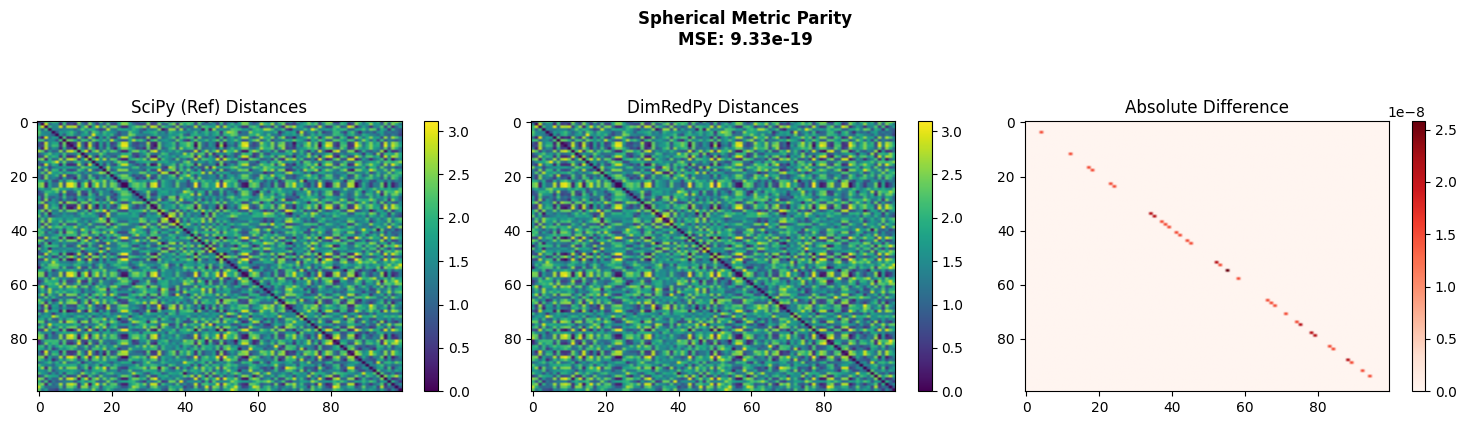

In [1]:
"""
Rigorous Verification of Metric Parity: Spherical Metric
"""

import numpy as np
import os
import sys
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

# Robust path detection for repo root
script_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in locals() else os.getcwd()
repo_root = os.path.abspath(os.path.join(script_dir, "..", ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from dimredpy.shared.metrics import SphericalMetric

# ---------------------------------------------------------------------------
# 1. Generate Synthetic Data
# ---------------------------------------------------------------------------
print("Generating synthetic coordinates for Spherical Metric parity...")
np.random.seed(42)
N = 100
D = 3
period = np.array([2*np.pi, 2*np.pi, 2*np.pi])
# Angles between 0 and period
X = np.random.uniform(0, 2*np.pi, size=(N, D))

# ---------------------------------------------------------------------------
# 2. Run Reference Framework (SciPy Cosine Distance on Embedded Sphere)
# ---------------------------------------------------------------------------
print("\n=======================================================")
print("          RUNNING REFERENCE FRAMEWORK (SciPy)")
print("=======================================================")

# Manually embed the angles onto the hyper-sphere
def embed_sphere(x, L):
    angles = x * (2.0 * np.pi / L)
    n = angles.shape[-1]
    result = np.zeros(angles.shape[:-1] + (n + 1,), dtype=float)
    carry = np.ones(angles.shape[:-1], dtype=float)
    for i in range(n):
        result[..., i] = carry * np.cos(angles[..., i])
        carry = carry * np.sin(angles[..., i])
    result[..., n] = carry
    return result

EX = embed_sphere(X, period)

# SciPy's cosine distance is 1 - dot(u, v)/(||u|| ||v||)
# Since they are unit vectors on a sphere, dot(u,v) = 1 - cosine_dist
# And Geodesic distance = arccos(dot(u,v))
cos_dist = cdist(EX, EX, metric='cosine')
dot_product = 1.0 - cos_dist

# Clip for numerical stability
dot_product = np.clip(dot_product, -1.0, 1.0)
ref_dist = np.arccos(dot_product)

print("-> SciPy spherical cdist finished.")

# ---------------------------------------------------------------------------
# 3. Run DimRedPy Framework
# ---------------------------------------------------------------------------
print("\n=======================================================")
print("          RUNNING DIMREDPY FRAMEWORK")
print("=======================================================")

metric = SphericalMetric(period=period)
dimred_dist = metric.pairwise(X)
print("-> DimRedPy SphericalMetric finished.")

# ---------------------------------------------------------------------------
# 4. Parity Validation
# ---------------------------------------------------------------------------
print("\n=======================================================")
print("          PARITY VALIDATION")
print("=======================================================")

mse = np.mean((ref_dist - dimred_dist) ** 2)
print(f"MSE on Spherical Distance Matrix: {mse:.6e}")

if mse < 1e-10:
    print("\nSUCCESS: DimRedPy SphericalMetric perfectly matches SciPy reference.")
else:
    print("\nFAILURE: Divergence detected in Spherical Metric parity.")

# ---------------------------------------------------------------------------
# 5. Visual Verification
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4), facecolor='white')
fig.suptitle(f"Spherical Metric Parity\nMSE: {mse:.2e}", fontweight='bold', y=1.05)

vmax = np.max(ref_dist)

im0 = axes[0].imshow(ref_dist, aspect='auto', cmap='viridis', vmax=vmax)
axes[0].set_title("SciPy (Ref) Distances")
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(dimred_dist, aspect='auto', cmap='viridis', vmax=vmax)
axes[1].set_title("DimRedPy Distances")
fig.colorbar(im1, ax=axes[1])

diff = np.abs(ref_dist - dimred_dist)
im2 = axes[2].imshow(diff, aspect='auto', cmap='Reds')
axes[2].set_title("Absolute Difference")
fig.colorbar(im2, ax=axes[2])

plt.tight_layout()
plot_path = os.path.join(script_dir, "verify_parity_metrics_spherical_plot.png")
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"Saved comparison plot to {plot_path}")
